# 🧪 EPI 2026 — Guía de resolución
## Análisis computacional de la producción de plástico con Python, *pandas* y *scikit-learn*

> **Asignatura:** Introducción a la Programación en Python &nbsp;·&nbsp; **Ponderación:** 20% (tercera nota)

Este notebook es una **guía paso a paso**. No es la solución final que deben entregar: es un andamiaje
que les muestra *cómo* abordar cada parte del proyecto. Su tarea es **adaptarlo a sus propios datos**,
**completar las celdas marcadas con `# ✏️ TODO`** y, sobre todo, **escribir sus interpretaciones y
conclusiones** (la parte escrita pesa tanto como el código).

### ¿Qué se evalúa? (rúbrica resumida)
1. **Correctitud del código** — que cargue datos, procese y grafique sin errores.
2. **Uso de pandas** — DataFrames, filtros, `groupby`, estadística descriptiva.
3. **Calidad de las visualizaciones** — con título, ejes y leyenda.
4. **Regresión lineal e interpretación** — pendiente, intercepto, R² y su lectura.
5. **Estructura y legibilidad** — comentarios, nombres descriptivos, orden.
6. **Proyección a 10 años** — con análisis crítico de su validez.
7. **Propuestas de solución** — fundamentadas y conectadas al modelo.

### Estructura de la guía
| Sección | Contenido | Criterio de rúbrica |
|---|---|---|
| 0 | Configuración del entorno | Correctitud |
| 1 | Análisis de datos con *pandas* | Uso de pandas |
| 2 | Visualizaciones | Calidad de visualizaciones |
| 3 | Regresión lineal + ajuste exponencial + proyección | Regresión / Proyección |
| 4 | Propuestas de solución | Propuestas |
| 5 | Conclusiones y checklist | Todos |

## 0 · Configuración del entorno

Si alguna librería no está instalada, ejecuten en una celda nueva:
```python
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl
```

In [1]:
# --- Librerías base ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn: modelo de regresión lineal
from sklearn.linear_model import LinearRegression

# Configuración estética para que los gráficos se vean prolijos
%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# seaborn es opcional; lo usamos solo si está disponible
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAY_SEABORN = True
except ImportError:
    HAY_SEABORN = False

print("Entorno listo ✅   | seaborn disponible:", HAY_SEABORN)
print("Versiones -> pandas", pd.__version__, "| numpy", np.__version__)

Entorno listo ✅   | seaborn disponible: True
Versiones -> pandas 3.0.2 | numpy 2.4.4


## 1 · Análisis de datos con *pandas*

> **Rúbrica:** *Utiliza correctamente DataFrames, filtros, agrupaciones y operaciones estadísticas con pandas.*

### 1.1 Importación de datos (CSV o Excel)

El proyecto pide importar datos reales de **producción mundial de plástico**. Para que esta guía
**funcione de inmediato**, generamos un conjunto de datos de ejemplo con forma realista y lo guardamos
en un CSV. **Reemplácenlo por su fuente oficial** (por ejemplo *Our World in Data*, *Plastics Europe*
u *OCDE*).

Para cargar **sus** datos, descomenten la línea que corresponda:
```python
df = pd.read_csv("mis_datos.csv")          # archivo CSV
df = pd.read_excel("mis_datos.xlsx")        # archivo Excel (requiere openpyxl)
```

In [2]:
# --- Generación de datos de EJEMPLO (reemplazar por datos reales) ------------
# Tendencia exponencial histórica: la producción se duplica cada ~9 años.
import os

ARCHIVO_CSV = "datos_produccion_plastico_ejemplo.csv"

if not os.path.exists(ARCHIVO_CSV):
    np.random.seed(42)  # reproducibilidad
    anios = np.arange(1950, 2024)
    produccion_base_1950 = 2.0          # millones de toneladas (Mt) en 1950
    tasa = 0.0742                       # tasa de crecimiento anual del enunciado
    tendencia = produccion_base_1950 * np.exp(tasa * (anios - 1950))
    ruido = np.random.normal(1.0, 0.07, size=len(anios))  # +-7% de variación
    produccion = np.round(tendencia * ruido, 1)

    df_generado = pd.DataFrame({"anio": anios, "produccion_mt": produccion})

    # Introducimos algunos "problemas" a propósito para practicar la limpieza:
    df_generado.loc[df_generado["anio"] == 1962, "produccion_mt"] = np.nan   # dato faltante
    df_generado.loc[df_generado["anio"] == 1987, "produccion_mt"] = np.nan   # dato faltante
    df_generado = pd.concat([df_generado, df_generado.iloc[[20]]], ignore_index=True)  # fila duplicada
    df_generado.to_csv(ARCHIVO_CSV, index=False)

# --- Carga de datos ---------------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)
# df = pd.read_excel("mis_datos.xlsx")   # <- usa esto para tu propio Excel

print("Datos cargados:", df.shape[0], "filas x", df.shape[1], "columnas")
df.head()

Datos cargados: 75 filas x 2 columnas


,anio,produccion_mt
0,1950,2.1
1,1951,2.1
2,1952,2.4
3,1953,2.8
4,1954,2.6


### 1.2 Exploración inicial

Antes de tocar nada, **miramos qué tenemos**: tamaño, tipos de datos, primeras filas y un resumen.
Esto evita errores más adelante.

In [3]:
print("Dimensiones (filas, columnas):", df.shape, "\n")
print("Tipos de datos y nulos:")
df.info()

Dimensiones (filas, columnas): (75, 2) 

Tipos de datos y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anio           75 non-null     int64  
 1   produccion_mt  73 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.3 KB


In [4]:
# Vistazo a las primeras y últimas filas
display(df.head())
display(df.tail())

,anio,produccion_mt
0,1950,2.1
1,1951,2.1
2,1952,2.4
3,1953,2.8
4,1954,2.6


,anio,produccion_mt
70,2020,369.5
71,2021,429.9
72,2022,417.0
73,2023,499.5
74,1970,9.7


### 1.3 Definición de variables

> **Rúbrica:** *identificación de variables independientes y dependientes.*

- **Variable independiente (X):** `anio` — el tiempo, que avanza por sí solo.
- **Variable dependiente (y):** `produccion_mt` — la producción de plástico, que **depende** del año.

En el análisis de regresión, X es lo que usamos para **predecir** y.

In [5]:
variable_independiente = "anio"
variable_dependiente = "produccion_mt"

print("Independiente (X):", variable_independiente)
print("Dependiente  (y):", variable_dependiente)

Independiente (X): anio
Dependiente  (y): produccion_mt


### 1.4 Limpieza y organización

> **Rúbrica:** *manejo de valores nulos, tipos de datos y estructuras tabulares.*

Pasos típicos: detectar nulos, eliminar duplicados, corregir tipos y ordenar.

In [6]:
# a) ¿Cuántos valores nulos hay por columna?
print("Valores nulos por columna:")
print(df.isnull().sum(), "\n")

# b) ¿Hay filas duplicadas?
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
anio             0
produccion_mt    2
dtype: int64 

Filas duplicadas: 1


In [7]:
# --- Limpieza ---------------------------------------------------------------
# 1) Eliminamos filas duplicadas
df = df.drop_duplicates()

# 2) Tratamos los valores nulos.
#    Como es una serie temporal continua, interpolar es más razonable que borrar.
df = df.sort_values("anio").reset_index(drop=True)
df["produccion_mt"] = df["produccion_mt"].interpolate(method="linear")

# 3) Verificamos los tipos de datos (anio debe ser entero; produccion, decimal)
df["anio"] = df["anio"].astype(int)
df["produccion_mt"] = df["produccion_mt"].astype(float)

# 4) Comprobación final
print("Nulos restantes:", df.isnull().sum().sum())
print("Duplicados restantes:", df.duplicated().sum())
df.info()

Nulos restantes: 0
Duplicados restantes: 0
<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anio           74 non-null     int64  
 1   produccion_mt  74 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.3 KB


### 1.5 Estadísticas descriptivas

> **Rúbrica:** *media, mediana, desviación estándar, mínimo, máximo.*

In [8]:
# Resumen automático de pandas
display(df["produccion_mt"].describe())

# Cálculo explícito de cada estadístico (útil para interpretarlos)
print("\n--- Producción de plástico (Mt) ---")
print(f"Media        : {df['produccion_mt'].mean():.2f}")
print(f"Mediana      : {df['produccion_mt'].median():.2f}")
print(f"Desv. estándar: {df['produccion_mt'].std():.2f}")
print(f"Mínimo       : {df['produccion_mt'].min():.2f}  (año {df.loc[df['produccion_mt'].idxmin(), 'anio']})")
print(f"Máximo       : {df['produccion_mt'].max():.2f}  (año {df.loc[df['produccion_mt'].idxmax(), 'anio']})")

count     74.000000
mean      86.114865
std      118.226356
min        2.100000
25%        7.250000
50%       29.575000
75%      119.475000
max      499.500000
Name: produccion_mt, dtype: float64


--- Producción de plástico (Mt) ---
Media        : 86.11
Mediana      : 29.58
Desv. estándar: 118.23
Mínimo       : 2.10  (año 1950)
Máximo       : 499.50  (año 2023)


> ✏️ **Interpreten ustedes:** ¿qué dice la diferencia entre la media y la mediana? ¿Y la magnitud
> de la desviación estándar respecto de la media? (Pista: cuando la mediana es mucho menor que la
> media, suele haber crecimiento acelerado al final de la serie.)

### 1.6 Crear nuevas variables

> **Rúbrica:** *Crear nuevas variables que enriquezcan las conclusiones.*

Variables derivadas que aportan lectura al fenómeno:
- **Variación interanual** (cuánto crece cada año, en Mt).
- **Crecimiento porcentual** anual.
- **Producción acumulada** (todo el plástico producido hasta ese año).
- **Década** (para agrupar).

In [9]:
df["variacion_mt"] = df["produccion_mt"].diff()                       # diferencia con el año anterior
df["crecimiento_pct"] = df["produccion_mt"].pct_change() * 100        # % de crecimiento anual
df["produccion_acumulada_mt"] = df["produccion_mt"].cumsum()          # acumulado histórico
df["decada"] = (df["anio"] // 10) * 10                                # 1950, 1960, ...

display(df.head(8))
print("Crecimiento porcentual promedio anual: "
      f"{df['crecimiento_pct'].mean():.2f}%")

,anio,produccion_mt,variacion_mt,crecimiento_pct,produccion_acumulada_mt,decada
0,1950,2.1,NaN,NaN,2.1,1950
1,1951,2.1,0.0,0.000000,4.2,1950
2,1952,2.4,0.3,14.285714,6.6,1950
3,1953,2.8,0.4,16.666667,9.4,1950
4,1954,2.6,-0.2,-7.142857,12.0,1950
5,1955,2.9,0.3,11.538462,14.9,1950
6,1956,3.5,0.6,20.689655,18.4,1950
7,1957,3.5,0.0,0.000000,21.9,1950


Crecimiento porcentual promedio anual: 8.16%


### 1.7 Patrones y tendencias: `groupby` y filtros

> **Rúbrica:** *Identificación de patrones mediante agrupaciones (groupby) y filtros.*

In [10]:
# Agrupación por década: producción promedio y total
resumen_decada = (
    df.groupby("decada")
      .agg(produccion_promedio_mt=("produccion_mt", "mean"),
           produccion_total_mt=("produccion_mt", "sum"),
           crecimiento_promedio_pct=("crecimiento_pct", "mean"))
      .round(2)
)
display(resumen_decada)

,produccion_promedio_mt,produccion_total_mt,crecimiento_promedio_pct
decada,,,
1950,2.94,29.40,7.81
1960,5.60,56.05,6.52
1970,12.36,123.60,9.06
1980,26.02,260.25,8.73
1990,54.37,543.70,6.42
2000,118.59,1185.90,10.14
2010,245.77,2457.70,6.81
2020,428.98,1715.90,12.19


In [11]:
# Filtros: ejemplos de subconjuntos de interés
desde_2000 = df[df["anio"] >= 2000]
print("Producción media desde el año 2000:",
      round(desde_2000["produccion_mt"].mean(), 2), "Mt")

anios_alto_crecimiento = df[df["crecimiento_pct"] > 10]
print("Años con crecimiento anual > 10%:",
      anios_alto_crecimiento["anio"].tolist()[:10], "...")

Producción media desde el año 2000: 223.31 Mt
Años con crecimiento anual > 10%: [1952, 1953, 1955, 1956, 1959, 1964, 1965, 1967, 1970, 1974] ...


## 2 · Visualizaciones de datos

> **Rúbrica:** *Visualizaciones claras, con títulos, etiquetas y colores apropiados.*
> Se piden **al menos tres tipos** de gráficos. **Todo gráfico** debe llevar **título, etiquetas de
> ejes y leyenda** (cuando corresponda).

### 2.1 Gráfico de línea — evolución temporal

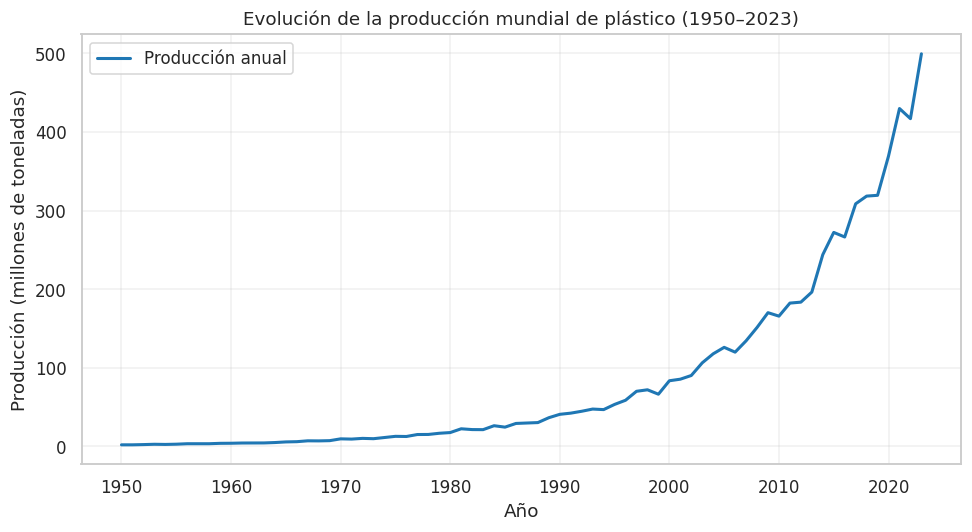

In [12]:
plt.figure()
plt.plot(df["anio"], df["produccion_mt"],
         color="#1f77b4", linewidth=2, label="Producción anual")
plt.title("Evolución de la producción mundial de plástico (1950–2023)")
plt.xlabel("Año")
plt.ylabel("Producción (millones de toneladas)")
plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Gráfico de barras — producción promedio por década

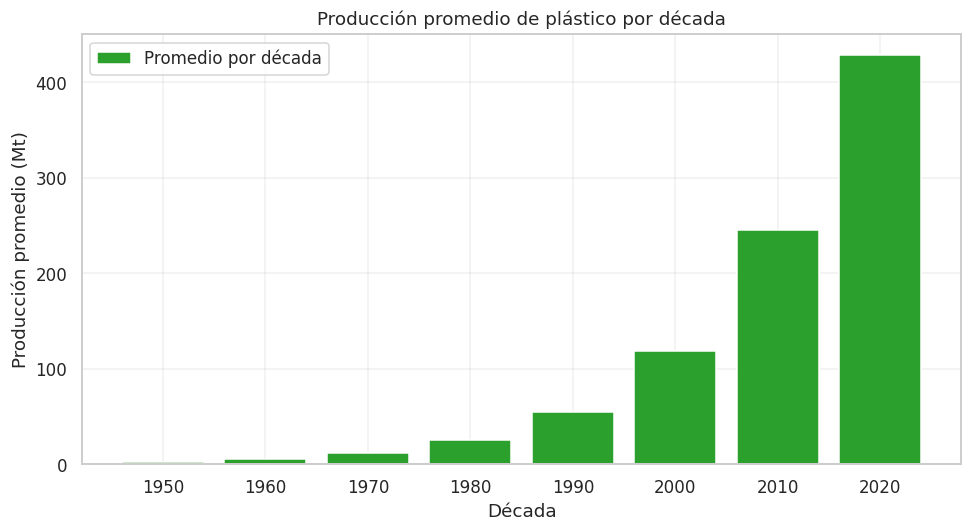

In [13]:
plt.figure()
plt.bar(resumen_decada.index.astype(str),
        resumen_decada["produccion_promedio_mt"],
        color="#2ca02c", label="Promedio por década")
plt.title("Producción promedio de plástico por década")
plt.xlabel("Década")
plt.ylabel("Producción promedio (Mt)")
plt.legend()
plt.tight_layout()
plt.show()

### 2.3 Histograma — distribución de la producción

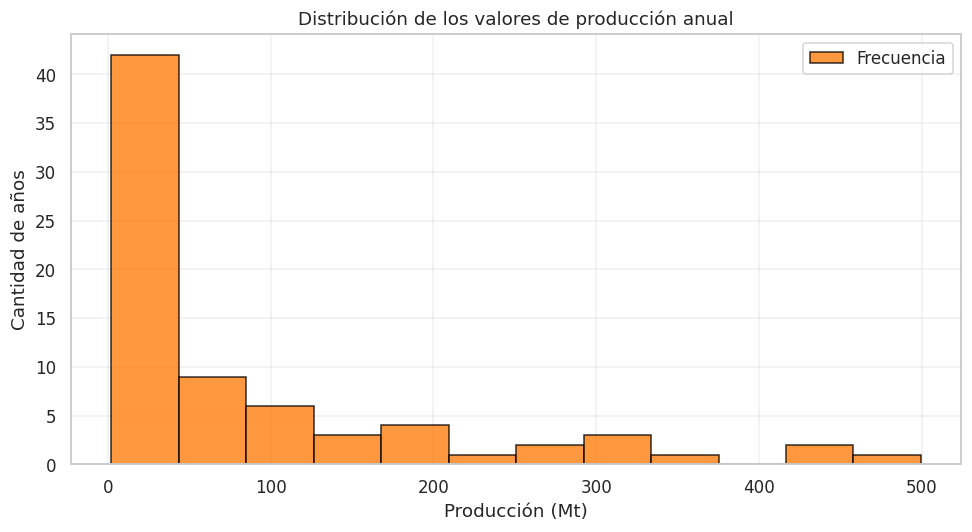

In [14]:
plt.figure()
plt.hist(df["produccion_mt"], bins=12,
         color="#ff7f0e", edgecolor="black", alpha=0.8, label="Frecuencia")
plt.title("Distribución de los valores de producción anual")
plt.xlabel("Producción (Mt)")
plt.ylabel("Cantidad de años")
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 (Extra) Crecimiento porcentual anual

Un cuarto gráfico que enriquece el análisis: muestra si el ritmo de crecimiento se acelera o frena.

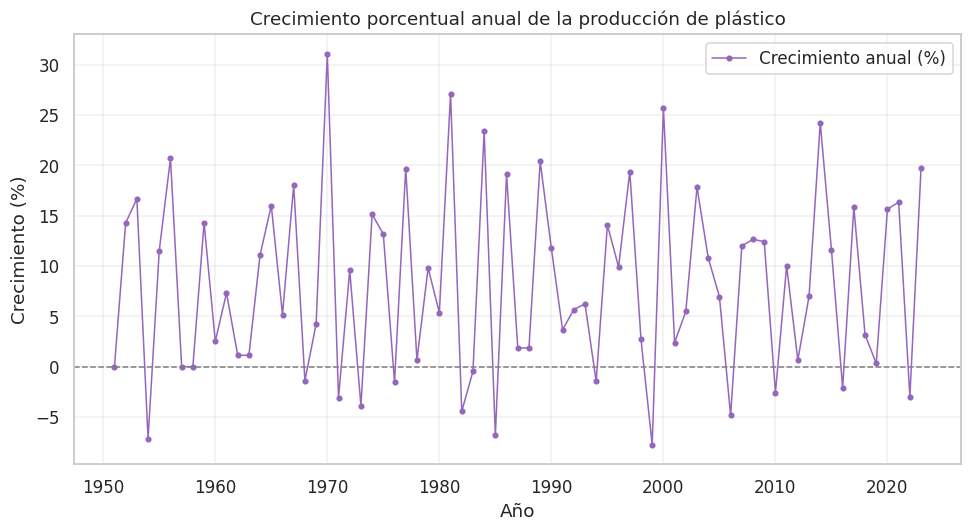

In [15]:
plt.figure()
plt.plot(df["anio"], df["crecimiento_pct"],
         color="#9467bd", marker="o", markersize=3, linewidth=1, label="Crecimiento anual (%)")
plt.axhline(0, color="gray", linewidth=1, linestyle="--")
plt.title("Crecimiento porcentual anual de la producción de plástico")
plt.xlabel("Año")
plt.ylabel("Crecimiento (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 3 · Proyección de la producción de plástico

> **Rúbrica:** *Implementa correctamente la regresión lineal, interpreta pendiente, intercepto y R²,
> y justifica el modelo con los datos.* + *Proyección a 10 años con análisis crítico.*

### 3.1 Regresión lineal con *scikit-learn*

Ajustamos una recta $\;\hat{y} = m\cdot x + b\;$ donde:
- $x$ = año (variable independiente)
- $\hat{y}$ = producción estimada
- $m$ = **pendiente** (cuántas Mt aumenta la producción por año)
- $b$ = **intercepto**
- $R^2$ = **coeficiente de determinación** (qué tan bien la recta explica los datos: 0 = nada, 1 = perfecto)

In [16]:
# scikit-learn espera X como matriz 2D (columnas), por eso usamos doble corchete
X = df[["anio"]].values            # variable independiente (2D)
y = df["produccion_mt"].values     # variable dependiente (1D)

modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

pendiente = modelo_lineal.coef_[0]
intercepto = modelo_lineal.intercept_
r2 = modelo_lineal.score(X, y)

print("--- Modelo de regresión lineal ---")
print(f"Pendiente (m)        : {pendiente:.3f} Mt por año")
print(f"Intercepto (b)       : {intercepto:.1f} Mt")
print(f"Coef. determinación R²: {r2:.4f}")
print(f"\nEcuación de la recta:  produccion = {pendiente:.3f} * anio + ({intercepto:.1f})")

--- Modelo de regresión lineal ---
Pendiente (m)        : 4.547 Mt por año
Intercepto (b)       : -8945.6 Mt
Coef. determinación R²: 0.6840

Ecuación de la recta:  produccion = 4.547 * anio + (-8945.6)


> ✏️ **Interpreten:**
> - La **pendiente** indica el aumento promedio de producción por cada año transcurrido.
> - El **R²** dice qué proporción de la variación queda explicada por la recta. Si es alto pero
>   los datos "se curvan", la recta puede ser una buena aproximación *global* pero mala en los extremos.
> - **Justifiquen** si el comportamiento es realmente lineal o si una curva (exponencial) describe
>   mejor el fenómeno. Esto conecta con la sección siguiente.

### 3.2 Comparación visual: datos reales vs. recta ajustada

> **Rúbrica:** *Visualización comparativa entre los datos reales y la recta de regresión ajustada.*

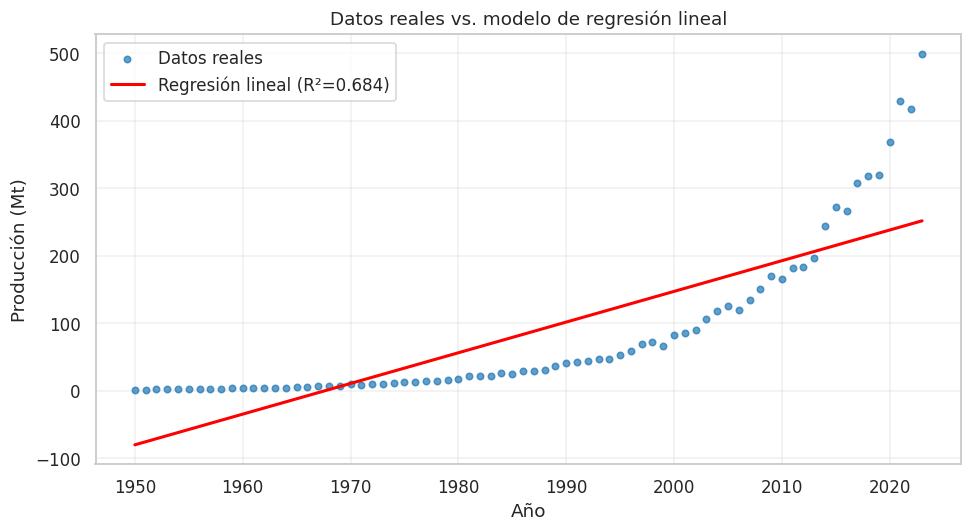

In [17]:
y_predicho = modelo_lineal.predict(X)

plt.figure()
plt.scatter(df["anio"], df["produccion_mt"],
            color="#1f77b4", s=18, alpha=0.7, label="Datos reales")
plt.plot(df["anio"], y_predicho,
         color="red", linewidth=2, label=f"Regresión lineal (R²={r2:.3f})")
plt.title("Datos reales vs. modelo de regresión lineal")
plt.xlabel("Año")
plt.ylabel("Producción (Mt)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Ajuste exponencial

El enunciado entrega un **modelo exponencial** para la producción:

$$\text{producción} = a \cdot e^{\,0{,}0742\,\cdot\,\text{AÑO}} \qquad R^2 = 0{,}9358$$

Un crecimiento exponencial con tasa $k = 0{,}0742$ implica que la producción **se duplica
aproximadamente cada** $\ln(2)/0{,}0742 \approx 9{,}3$ **años** — coherente con la historia del plástico.

> ⚠️ **Sobre la constante $a$:** en el enunciado aparece como $7\times10^{-58}$, pero su magnitud
> exacta depende de las **unidades** y de la **fuente** de datos (y la transcripción desde el PDF puede
> alterar el exponente). Por eso, la forma **robusta** de obtener $a$ es **ajustarla a *sus* datos**
> mediante una regresión lineal sobre el logaritmo: si $y = a\,e^{k\cdot x}$, entonces
> $\ln(y) = \ln(a) + k\cdot x$, ¡que es una recta! Así recuperamos $k$ y $a$ desde los datos.

In [18]:
# --- Ajuste exponencial vía regresión lineal sobre ln(y) --------------------
ln_y = np.log(df["produccion_mt"].values)

modelo_log = LinearRegression()
modelo_log.fit(X, ln_y)

k_estimado = modelo_log.coef_[0]            # debería acercarse a 0.0742
ln_a = modelo_log.intercept_
a_estimado = np.exp(ln_a)
r2_exponencial = modelo_log.score(X, ln_y)

print("--- Modelo exponencial ajustado a los datos ---")
print(f"k (tasa de crecimiento): {k_estimado:.4f}   (enunciado: 0.0742)")
print(f"a (constante)          : {a_estimado:.3e}")
print(f"R² (en escala log)     : {r2_exponencial:.4f}   (enunciado: 0.9358)")

def produccion_exponencial(anio):
    """Modelo exponencial AJUSTADO a los datos: a * e^(k*anio)."""
    return a_estimado * np.exp(k_estimado * np.asarray(anio, dtype=float))

def produccion_exponencial_enunciado(anio, a=7e-58, k=0.0742):
    """Modelo EXACTO del enunciado. Ajusta 'a' al valor de tu PDF si difiere."""
    return a * np.exp(k * np.asarray(anio, dtype=float))

--- Modelo exponencial ajustado a los datos ---
k (tasa de crecimiento): 0.0747   (enunciado: 0.0742)
a (constante)          : 1.158e-63
R² (en escala log)     : 0.9984   (enunciado: 0.9358)


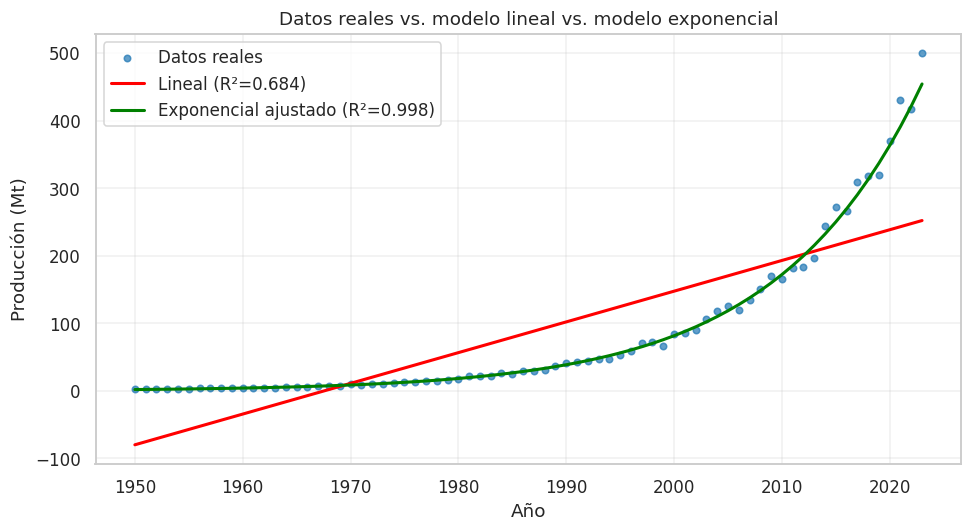

In [19]:
# Comparación de los dos modelos exponenciales sobre el rango histórico
plt.figure()
plt.scatter(df["anio"], df["produccion_mt"], color="#1f77b4", s=18, alpha=0.7, label="Datos reales")
plt.plot(df["anio"], y_predicho, color="red", linewidth=2, label=f"Lineal (R²={r2:.3f})")
plt.plot(df["anio"], produccion_exponencial(df["anio"]), color="green", linewidth=2,
         label=f"Exponencial ajustado (R²={r2_exponencial:.3f})")
plt.title("Datos reales vs. modelo lineal vs. modelo exponencial")
plt.xlabel("Año")
plt.ylabel("Producción (Mt)")
plt.legend()
plt.tight_layout()
plt.show()

> ✏️ **Comparen ambos modelos:** ¿cuál sigue mejor la curvatura de los datos? Suele ocurrir que la
> recta subestima los valores recientes y el modelo exponencial los captura mejor. Argumenten con el R².

### 3.4 Proyección a 10 años

> **Rúbrica:** *Proyección bien implementada con gráfico y análisis crítico de su validez.*

Proyectamos **ambos** modelos (lineal y exponencial) hacia el futuro y los comparamos.

In [20]:
ultimo_anio = int(df["anio"].max())
anios_futuros = np.arange(ultimo_anio + 1, ultimo_anio + 11)   # próximos 10 años

# Proyección lineal
X_futuro = anios_futuros.reshape(-1, 1)
proy_lineal = modelo_lineal.predict(X_futuro)

# Proyección exponencial (modelo ajustado a los datos)
proy_exp = produccion_exponencial(anios_futuros)

tabla_proyeccion = pd.DataFrame({
    "anio": anios_futuros,
    "proyeccion_lineal_mt": np.round(proy_lineal, 1),
    "proyeccion_exponencial_mt": np.round(proy_exp, 1),
})
display(tabla_proyeccion)

,anio,proyeccion_lineal_mt,proyeccion_exponencial_mt
0,2024,256.6,489.4
1,2025,261.2,527.3
2,2026,265.7,568.2
3,2027,270.2,612.2
4,2028,274.8,659.7
5,2029,279.3,710.8
6,2030,283.9,765.9
7,2031,288.4,825.3
8,2032,293.0,889.3
9,2033,297.5,958.2


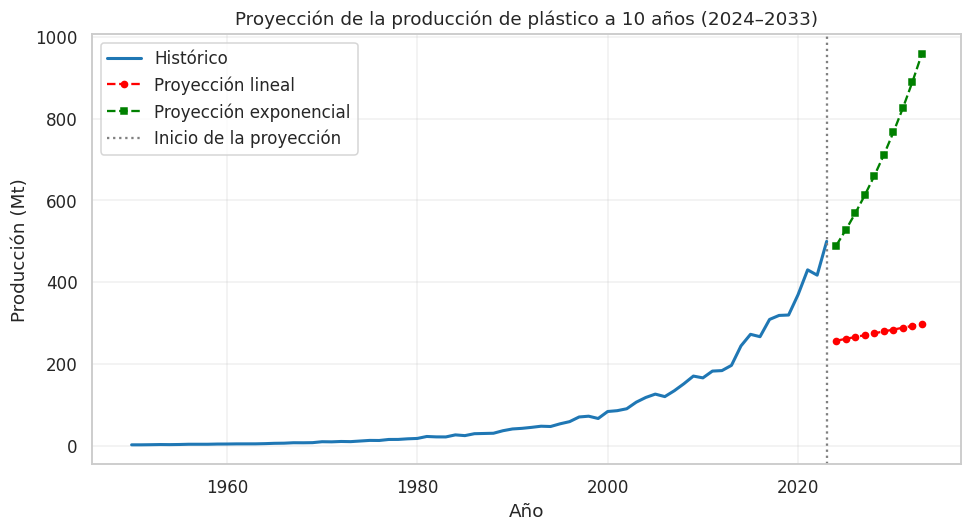

In [21]:
plt.figure()
# Histórico
plt.plot(df["anio"], df["produccion_mt"], color="#1f77b4", linewidth=2, label="Histórico")
# Proyecciones
plt.plot(anios_futuros, proy_lineal, color="red", linestyle="--", marker="o",
         markersize=4, label="Proyección lineal")
plt.plot(anios_futuros, proy_exp, color="green", linestyle="--", marker="s",
         markersize=4, label="Proyección exponencial")
plt.axvline(ultimo_anio, color="gray", linestyle=":", label="Inicio de la proyección")
plt.title(f"Proyección de la producción de plástico a 10 años ({ultimo_anio+1}–{ultimo_anio+10})")
plt.xlabel("Año")
plt.ylabel("Producción (Mt)")
plt.legend()
plt.tight_layout()
plt.show()

> ✏️ **Análisis crítico (obligatorio para Nivel 4):**
> - ¿Es realista que el crecimiento **exponencial** continúe indefinidamente? ¿Qué factores (saturación
>   de mercado, regulaciones, reciclaje) podrían frenarlo?
> - El modelo **lineal** ¿subestima el futuro? ¿Por qué?
> - Una proyección es **una hipótesis**, no una certeza. ¿Qué supuestos asume cada modelo?

## 4 · Propuestas de solución

> **Rúbrica:** *Propone estrategias fundamentadas y proyecta su impacto con el modelo de regresión
> desarrollado.*

Esta sección es **principalmente escrita**, pero deben **conectarla con números**. El esqueleto:

1. **Diagnóstico** — ¿qué muestran los datos? (crecimiento sostenido, aceleración, etc.)
2. **Estrategias** — reciclaje, reducción de plásticos de un solo uso, economía circular, sustitución
   por materiales biodegradables, responsabilidad extendida del productor…
3. **Proyección del impacto** — usar el modelo para estimar qué pasaría **si** se aplicara una medida.

### 4.1 Ejemplo: escenario de mitigación

Modelamos una hipótesis: que a partir del próximo año una política logre **reducir la tasa de
crecimiento** (por ejemplo, mediante reciclaje y reducción de un solo uso), de modo que la producción
crezca menos cada año respecto del escenario base.

In [22]:
# Escenario base: proyección exponencial (sin intervención)
escenario_base = produccion_exponencial(anios_futuros)

# Escenario con mitigación: aplicamos una reducción anual acumulativa
# (ej.: cada año se evita un 3% adicional respecto del escenario base)
reduccion_anual = 0.03   # ✏️ ajusten este parámetro y justifíquenlo
factores = (1 - reduccion_anual) ** np.arange(1, len(anios_futuros) + 1)
escenario_mitigado = escenario_base * factores

tabla_impacto = pd.DataFrame({
    "anio": anios_futuros,
    "sin_intervencion_mt": np.round(escenario_base, 1),
    "con_mitigacion_mt": np.round(escenario_mitigado, 1),
    "plastico_evitado_mt": np.round(escenario_base - escenario_mitigado, 1),
})
display(tabla_impacto)

total_evitado = (escenario_base - escenario_mitigado).sum()
print(f"\nPlástico total evitado en 10 años: {total_evitado:,.1f} Mt")

,anio,sin_intervencion_mt,con_mitigacion_mt,plastico_evitado_mt
0,2024,489.4,474.7,14.7
1,2025,527.3,496.1,31.2
2,2026,568.2,518.6,49.6
3,2027,612.2,542.0,70.2
4,2028,659.7,566.5,93.2
5,2029,710.8,592.1,118.7
6,2030,765.9,618.8,147.1
7,2031,825.3,646.8,178.5
8,2032,889.3,676.0,213.2
9,2033,958.2,706.6,251.6



Plástico total evitado en 10 años: 1,168.0 Mt


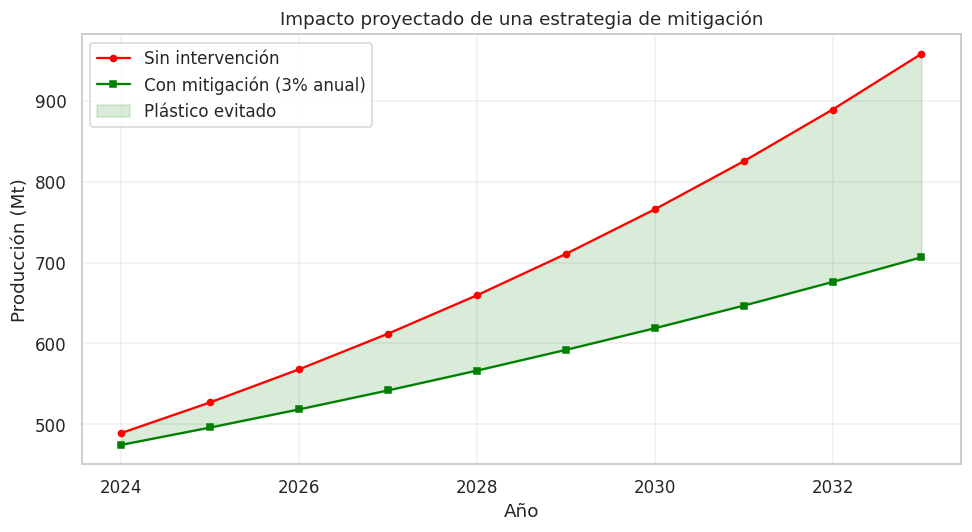

In [23]:
plt.figure()
plt.plot(anios_futuros, escenario_base, color="red", marker="o", markersize=4,
         label="Sin intervención")
plt.plot(anios_futuros, escenario_mitigado, color="green", marker="s", markersize=4,
         label=f"Con mitigación ({int(reduccion_anual*100)}% anual)")
plt.fill_between(anios_futuros, escenario_mitigado, escenario_base,
                 color="green", alpha=0.15, label="Plástico evitado")
plt.title("Impacto proyectado de una estrategia de mitigación")
plt.xlabel("Año")
plt.ylabel("Producción (Mt)")
plt.legend()
plt.tight_layout()
plt.show()

> ✏️ **Redacten su propuesta** respondiendo:
> - ¿Qué estrategia concreta proponen y por qué? (fundamenten con los datos del análisis)
> - ¿Qué supuesto representa el parámetro de reducción? ¿Es alcanzable?
> - Según el modelo, ¿cuánto plástico se evitaría? ¿Es significativo frente al total proyectado?

## 5 · Conclusiones y checklist final

### 5.1 Conclusiones (a completar por el equipo)

> ✏️ Escriban 1–2 párrafos cerrando el ciclo **diagnóstico → estudio → propuesta**:
> qué encontraron en los datos, qué modelo describe mejor el fenómeno, qué proyecta a futuro y
> qué solución proponen con su impacto estimado.

### 5.2 Checklist contra la rúbrica

| ✔️ | Criterio | Dónde se cubre |
|---|---|---|
| ☐ | El código corre sin errores | Todo el notebook |
| ☐ | Uso de `DataFrame`, filtros, `groupby`, estadística | Sección 1 |
| ☐ | Manejo de nulos y tipos de datos | 1.4 |
| ☐ | Nuevas variables creadas | 1.6 |
| ☐ | Al menos 3 gráficos con título, ejes y leyenda | Sección 2 |
| ☐ | Regresión lineal con pendiente, intercepto y R² | 3.1 |
| ☐ | Interpretación de los parámetros | 3.1 (texto) |
| ☐ | Comparación datos reales vs. recta | 3.2 |
| ☐ | Ajuste exponencial | 3.3 |
| ☐ | Proyección a 10 años con análisis crítico | 3.4 |
| ☐ | Propuestas fundamentadas + impacto con el modelo | Sección 4 |
| ☐ | Código comentado, ordenado y con nombres claros | Todo |
| ☐ | Conclusiones escritas | 5.1 |

### 5.3 Consejos para la nota máxima (Nivel 4)
- **No basta con que corra:** la rúbrica premia la **interpretación**. Por cada resultado, escriban *qué significa*.
- **Reemplacen los datos de ejemplo** por una fuente real y **citen la fuente**.
- **Comenten el código** y usen nombres descriptivos (lo están viendo modelado aquí).
- **Conecten todo:** el diagnóstico justifica la propuesta y el modelo cuantifica su impacto.

¡Éxito con el EPI 2026! 🌍♻️